# TS-SatFire -- Active Fire Detection -- HybridAFNet v2

## Changes from v1
- **Focal loss** replaces the CE component inside DiceCE (gamma=2.0). Focal loss down-weights easy background pixels and forces the model to focus on hard fire / boundary pixels, directly attacking the precision oscillation seen in v1.
- **CE_FIRE_WEIGHT reduced** from 10.0 to 5.0. v1 was over-weighting fire which pushed recall very high (0.84) but left precision low (0.64). Halving the weight balances precision/recall and brings the optimal threshold closer to 0.50.
- **Test windowing fixed**: sliding window step at test/val time is now 1 (fully overlapping) instead of T=6. This guarantees every fire day is covered by at least one window, eliminating the four zero-F1 fires caused by window misalignment in v1.
- **Augmentation extended**: random 90-degree rotation added alongside the existing H/V flip.
- **Time steps reduced to T=4**: paper ablation (Table 5) shows SwinUNETR-3D gains +0.04 F1 going from TS=6 to TS=2 on AF. T=4 is a balanced compromise -- more temporal context than T=2, lower memory than T=6, faster per-epoch time.
- Output files renamed `af_hybrid_v2_*`.


In [1]:
import os, sys, glob, json, math, random, warnings, time, zipfile
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import rasterio

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}  : {props.name}  ({props.total_memory/1024**3:.1f} GB)')


PyTorch  : 2.9.0+cu126
CUDA     : True
  GPU 0  : Tesla T4  (14.6 GB)
  GPU 1  : Tesla T4  (14.6 GB)


## Configuration

All hyperparameters in one place.

In [2]:
# Paths
DATA_ROOT  = '/kaggle/input/datasets/z789456sx/ts-satfire/ts-satfire'
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Resume from a previous run (set to None for fresh training)
RESUME_WEIGHTS_DIR = None
FINETUNE_LR_MAX    = 5e-5

# Output file names  (v2)
CKPT_BEST  = os.path.join(OUTPUT_DIR, 'af_hybrid_v2_best.pt')
CKPT_LAST  = os.path.join(OUTPUT_DIR, 'af_hybrid_v2_last.pt')
STATS_PATH = os.path.join(OUTPUT_DIR, 'norm_stats_af_v2.npz')
META_PATH  = os.path.join(OUTPUT_DIR, 'run_meta_af_v2.json')
HIST_PATH  = os.path.join(OUTPUT_DIR, 'history_af_v2.json')

# Dataset
SEED            = 42
TIME_STEPS      = 4      # reduced from 6 -- paper ablation shows shorter TS improves AF F1
CHANS_PER_STEP  = 8      # 6 spectral day + 2 night
PATCH_SIZE      = 128
VAL_FRACTION    = 0.20
TRAIN_INTERVAL  = 1      # dense sliding window for training
VAL_INTERVAL    = 1      # overlapping windows at val time (fixed from v1 VAL_INTERVAL=3)
MIN_FIRE_PIXELS = 10
MAX_NEG_RATIO   = 2

# Model  (same architecture as v1)
BASE_CH         = 48
N_HEADS         = 4
N_TRANS_LAYERS  = 4
TRANS_FF_DIM    = 512
TRANS_DROPOUT   = 0.1

# Training
NUM_EPOCHS      = 35 
BATCH_SIZE      = 8      # can increase slightly because T=4 (was 6 at T=6)
LR_MAX          = 2e-4
WEIGHT_DECAY    = 1e-4
GRAD_CLIP       = 1.0

# Loss  -- KEY CHANGE from v1
DICE_WEIGHT     = 0.5
FOCAL_WEIGHT    = 0.5    # replaces CE_WEIGHT -- Focal loss instead of CE
FOCAL_GAMMA     = 2.0    # focal exponent -- down-weights easy negatives
CE_FIRE_WEIGHT  = 5.0    # reduced from 10.0 -- less aggressive fire upweighting

# Inference
INFER_THRESHOLD = 0.5
SAVE_FIGURES    = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'Device          : {device}')
print(f'TIME_STEPS      : {TIME_STEPS}')
print(f'CHANS_PER_STEP  : {CHANS_PER_STEP}')
print(f'BASE_CH         : {BASE_CH}')
print(f'N_TRANS_LAYERS  : {N_TRANS_LAYERS}')
print(f'N_HEADS         : {N_HEADS}')
print(f'NUM_EPOCHS      : {NUM_EPOCHS}')
print(f'BATCH_SIZE      : {BATCH_SIZE}')
print(f'LR_MAX          : {LR_MAX}')
print(f'FOCAL_GAMMA     : {FOCAL_GAMMA}')
print(f'CE_FIRE_WEIGHT  : {CE_FIRE_WEIGHT}')


Device          : cuda
TIME_STEPS      : 4
CHANS_PER_STEP  : 8
BASE_CH         : 48
N_TRANS_LAYERS  : 4
N_HEADS         : 4
NUM_EPOCHS      : 35
BATCH_SIZE      : 8
LR_MAX          : 0.0002
FOCAL_GAMMA     : 2.0
CE_FIRE_WEIGHT  : 5.0


## Dataset discovery and splits

In [3]:
if not os.path.isdir(DATA_ROOT):
    raise RuntimeError(f'Dataset not found at {DATA_ROOT}')

all_dirs = sorted([
    d for d in glob.glob(os.path.join(DATA_ROOT, '*'))
    if os.path.isdir(d)
])

REQUIRED = {'VIIRS_Day', 'VIIRS_Night'}
fire_dirs = [d for d in all_dirs if REQUIRED.issubset(set(os.listdir(d)))]
print(f'Total folders    : {len(all_dirs)}')
print(f'Valid fires      : {len(fire_dirs)}')

def count_day_files(fd):
    return len(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))

fire_dirs = [fd for fd in fire_dirs if count_day_files(fd) >= TIME_STEPS]
print(f'Fires with >= {TIME_STEPS} days : {len(fire_dirs)}')

AF_TEST_NAMED = {
    'currowan_fire', 'thomas_fire', 'camp_fire', 'tubbs_fire',
    'creek_fire', 'dixie_fire', 'mosquito_fire', 'lytton_fire',
    'blue_ridge_fire', 'double_creek_fire', 'eagle_bluff_fire',
    'calfcanyon_fire', 'carr_fire',
}

def is_af_test(fd):
    return os.path.basename(fd) in AF_TEST_NAMED

test_fires  = [fd for fd in fire_dirs if is_af_test(fd)]
train_pool  = [fd for fd in fire_dirs if not is_af_test(fd)]

rng = random.Random(SEED)
rng.shuffle(train_pool)
n_val       = max(1, int(len(train_pool) * VAL_FRACTION))
val_fires   = train_pool[:n_val]
train_fires = train_pool[n_val:]

print(f'\nSplit summary:')
print(f'  train : {len(train_fires)} fires')
print(f'  val   : {len(val_fires)} fires')
print(f'  test  : {len(test_fires)} fires')

if len(test_fires) < 5:
    print('WARNING: fewer than 5 AF test fires found.')

run_meta = {
    'version'        : 'af_v2',
    'TIME_STEPS'     : TIME_STEPS,
    'CHANS_PER_STEP' : CHANS_PER_STEP,
    'PATCH_SIZE'     : PATCH_SIZE,
    'BASE_CH'        : BASE_CH,
    'N_HEADS'        : N_HEADS,
    'N_TRANS_LAYERS' : N_TRANS_LAYERS,
    'FOCAL_GAMMA'    : FOCAL_GAMMA,
    'CE_FIRE_WEIGHT' : CE_FIRE_WEIGHT,
    'INFER_THRESHOLD': INFER_THRESHOLD,
    'SEED'           : SEED,
    'train_fire_ids' : [os.path.basename(f) for f in train_fires],
    'val_fire_ids'   : [os.path.basename(f) for f in val_fires],
    'test_fire_ids'  : [os.path.basename(f) for f in test_fires],
}
with open(META_PATH, 'w') as fh:
    json.dump(run_meta, fh, indent=2)
print(f'Saved {META_PATH}')


Total folders    : 192
Valid fires      : 178
Fires with >= 4 days : 177

Split summary:
  train : 132 fires
  val   : 33 fires
  test  : 12 fires
Saved /kaggle/working/run_meta_af_v2.json


## Normalisation statistics

Identical two-pass pipeline to v1 -- must match exactly for fair comparison.

In [4]:
CHAN_NAMES = ['I1 (Red)', 'I2 (NIR)', 'I3 (SWIR)', 'I4 (MIR day)',
              'I5 (LWIR day)', 'M11 (SWIR2)', 'I4 Night', 'I5 Night']

def load_frame_af(fire_dir, day_path, return_label=False):
    """
    Load one day frame: 6 spectral day bands + 2 night bands = 8 channels.
    Optionally also returns the AF label (band 7 of day file, values >= 7 = fire).
    This avoids a separate rasterio open for the label.
    """
    night_dir  = os.path.join(fire_dir, 'VIIRS_Night')
    day_name   = os.path.basename(day_path)
    night_path = os.path.join(night_dir, day_name.replace('_VIIRS_Day', '_VIIRS_Night'))

    # Day bands 1-6 (indices 0-5), band 7 (index 6) is the AF mask
    with rasterio.open(day_path) as src:
        day_arr = src.read().astype(np.float32)   # (>=7, H, W)
    day_bands = day_arr[:6]                        # I1-I5, M11

    label = None
    if return_label:
        if day_arr.shape[0] >= 7:
            label = (day_arr[6] >= 7).astype(np.float32)
        else:
            label = np.zeros(day_arr.shape[1:], dtype=np.float32)

    # Night bands I4 and I5 (indices 0-1 from night file)
    if os.path.exists(night_path):
        with rasterio.open(night_path) as src:
            night_arr = src.read().astype(np.float32)
        night_bands = night_arr[:2] if night_arr.shape[0] >= 2 else np.zeros((2, *day_bands.shape[1:]), dtype=np.float32)
    else:
        night_bands = np.zeros((2, *day_bands.shape[1:]), dtype=np.float32)

    frame = np.concatenate([day_bands, night_bands], axis=0)  # (8, H, W)
    if return_label:
        return frame, label
    return frame


# Two-pass normalisation: collect statistics on a sample of training fires
print('Computing normalisation statistics on training fires...')
N_SAMPLE = min(30, len(train_fires))
sample_fires = random.sample(train_fires, N_SAMPLE)

all_vals = [[] for _ in range(CHANS_PER_STEP)]
for fd in tqdm(sample_fires, desc='Norm stats pass 1'):
    day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
    for dp in day_files[:3]:
        try:
            frame = load_frame_af(fd, dp, return_label=False)
            for c in range(CHANS_PER_STEP):
                vals = frame[c].ravel()
                vals = vals[np.isfinite(vals)]
                if len(vals):
                    all_vals[c].append(vals)
        except Exception:
            pass

CLIP_LO = np.array([np.percentile(np.concatenate(v),  1) if v else 0.0 for v in all_vals])
CLIP_HI = np.array([np.percentile(np.concatenate(v), 99) if v else 1.0 for v in all_vals])

# Pass 2: mean / std after clipping
sums = np.zeros(CHANS_PER_STEP)
sq   = np.zeros(CHANS_PER_STEP)
cnt  = np.zeros(CHANS_PER_STEP)
for fd in tqdm(sample_fires, desc='Norm stats pass 2'):
    day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
    for dp in day_files[:3]:
        try:
            frame = load_frame_af(fd, dp, return_label=False)
            frame = np.clip(frame,
                            CLIP_LO[:, None, None],
                            CLIP_HI[:, None, None])
            for c in range(CHANS_PER_STEP):
                v = frame[c].ravel()
                v = v[np.isfinite(v)]
                sums[c] += v.sum()
                sq[c]   += (v**2).sum()
                cnt[c]  += len(v)
        except Exception:
            pass

CHAN_MEANS = sums / np.maximum(cnt, 1)
CHAN_STDS  = np.sqrt(np.maximum(sq / np.maximum(cnt, 1) - CHAN_MEANS**2, 1e-6))

np.savez(STATS_PATH,
         means=CHAN_MEANS, stds=CHAN_STDS,
         clip_lo=CLIP_LO, clip_hi=CLIP_HI)

print(f'\nSaved {STATS_PATH}')
print(f'{"Chan":<4}  {"Name":<22}  {"Mean":>10}  {"Std":>10}')
print('-' * 52)
for c, name in enumerate(CHAN_NAMES):
    print(f'{c:<4}  {name:<22}  {CHAN_MEANS[c]:>10.3f}  {CHAN_STDS[c]:>10.3f}')


Computing normalisation statistics on training fires...


Norm stats pass 1:   0%|          | 0/30 [00:00<?, ?it/s]

Norm stats pass 2:   0%|          | 0/30 [00:00<?, ?it/s]


Saved /kaggle/working/norm_stats_af_v2.npz
Chan  Name                          Mean         Std
----------------------------------------------------
0     I1 (Red)                    17.133      14.603
1     I2 (NIR)                    26.958      14.208
2     I3 (SWIR)                   22.726      11.037
3     I4 (MIR day)               311.008      14.035
4     I5 (LWIR day)              299.290      18.219
5     M11 (SWIR2)                 16.040       9.470
6     I4 Night                   282.961      10.214
7     I5 Night                   282.208      10.983


## Dataset class

Key change from v1: `VAL_INTERVAL=1` (overlapping windows) and random 90-degree rotation augmentation added.

In [5]:
class AFDataset(Dataset):

    def __init__(self, fire_dirs, time_steps=TIME_STEPS,
                 interval=1, patch_size=PATCH_SIZE,
                 means=None, stds=None,
                 clip_lo=None, clip_hi=None,
                 augment=False):
        self.T          = time_steps
        self.interval   = interval
        self.patch_size = patch_size
        self.means      = means
        self.stds       = stds
        self.clip_lo    = clip_lo
        self.clip_hi    = clip_hi
        self.augment    = augment
        self.samples    = []
        self._build_index(fire_dirs)

    def _build_index(self, fire_dirs):
        n_pos = n_neg = n_neg_kept = skipped = 0
        rng = random.Random(SEED)

        for fd in fire_dirs:
            day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
            if len(day_files) < self.T:
                skipped += 1
                continue
            try:
                with rasterio.open(day_files[0]) as src:
                    if src.count < 7:
                        skipped += 1
                        continue
            except Exception:
                skipped += 1
                continue

            n = len(day_files)
            start = 0
            while start + self.T <= n:
                last_day = day_files[start + self.T - 1]
                lbl      = None
                try:
                    with rasterio.open(last_day) as src:
                        if src.count >= 7:
                            arr = src.read(7).astype(np.float32)
                            lbl = (arr >= 7).astype(np.float32)
                except Exception:
                    pass

                if lbl is None:
                    start += self.interval
                    continue

                if self.patch_size:
                    H, W = lbl.shape
                    if H > self.patch_size and W > self.patch_size:
                        r0 = (H - self.patch_size) // 2
                        c0 = (W - self.patch_size) // 2
                        p  = self.patch_size
                        lbl = lbl[r0:r0+p, c0:c0+p]

                fire_px     = int(lbl.sum())
                is_positive = fire_px >= MIN_FIRE_PIXELS

                if is_positive:
                    n_pos += 1
                    keep   = True
                else:
                    n_neg += 1
                    keep   = rng.random() < 1.0 / (MAX_NEG_RATIO + 1)
                    if keep:
                        n_neg_kept += 1

                if keep:
                    self.samples.append({
                        'fire_dir'  : fd,
                        'day_files' : day_files,
                        'start'     : start,
                        'end'       : start + self.T - 1,
                    })
                start += self.interval

        print(f'AFDataset: {len(self.samples)} samples '
              f'(T={self.T}, interval={self.interval}, skipped={skipped})')
        print(f'  positive patches : {n_pos}')
        print(f'  neg kept/total   : {n_neg_kept}/{n_neg}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s         = self.samples[idx]
        fd        = s['fire_dir']
        win_files = s['day_files'][s['start'] : s['end'] + 1]

        frames = []
        H = W  = None
        for t, dp in enumerate(win_files):
            is_last = (t == len(win_files) - 1)
            if is_last:
                frame, label = load_frame_af(fd, dp, return_label=True)
            else:
                frame = load_frame_af(fd, dp, return_label=False)
            if H is None:
                H, W = frame.shape[1], frame.shape[2]
            frames.append(frame[:, :H, :W])

        label = label[:H, :W]
        stack = np.stack(frames, axis=0)   # (T, 8, H, W)

        if self.clip_lo is not None:
            stack = np.clip(stack,
                            self.clip_lo[None, :, None, None],
                            self.clip_hi[None, :, None, None])
        if self.means is not None:
            stack = (stack - self.means[None, :, None, None]) /                      self.stds[ None, :, None, None]
        stack = np.nan_to_num(stack, nan=0.0, posinf=0.0, neginf=0.0)

        # Centre crop
        if self.patch_size and H > self.patch_size and W > self.patch_size:
            r0 = (H - self.patch_size) // 2
            c0 = (W - self.patch_size) // 2
            p  = self.patch_size
            stack = stack[:, :, r0:r0+p, c0:c0+p]
            label = label[r0:r0+p, c0:c0+p]

        # Augmentation: H-flip, V-flip, random 90-degree rotation
        if self.augment:
            if random.random() > 0.5:
                stack = np.flip(stack, axis=-1).copy()
                label = np.flip(label, axis=-1).copy()
            if random.random() > 0.5:
                stack = np.flip(stack, axis=-2).copy()
                label = np.flip(label, axis=-2).copy()
            k = random.randint(0, 3)
            if k > 0:
                stack = np.rot90(stack, k=k, axes=(-2, -1)).copy()
                label = np.rot90(label, k=k, axes=(0,  1 )).copy()

        x = torch.from_numpy(stack.transpose(1, 0, 2, 3).copy()).float()  # (C, T, H, W)
        y = torch.from_numpy(label.copy()).long()
        return x, y


print('AFDataset defined.')


AFDataset defined.


## DataLoaders

In [6]:
train_ds = AFDataset(
    fire_dirs  = train_fires,
    time_steps = TIME_STEPS,
    interval   = TRAIN_INTERVAL,
    patch_size = PATCH_SIZE,
    means=CHAN_MEANS, stds=CHAN_STDS, clip_lo=CLIP_LO, clip_hi=CLIP_HI,
    augment    = True,
)
val_ds = AFDataset(
    fire_dirs  = val_fires,
    time_steps = TIME_STEPS,
    interval   = VAL_INTERVAL,   # 1 = overlapping windows (fixed from v1)
    patch_size = PATCH_SIZE,
    means=CHAN_MEANS, stds=CHAN_STDS, clip_lo=CLIP_LO, clip_hi=CLIP_HI,
    augment    = False,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True,
                          persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True,
                          persistent_workers=True)

print(f'Train batches / epoch : {len(train_loader)}')
print(f'Val   batches / epoch : {len(val_loader)}')

xb, yb = next(iter(train_loader))
print(f'\nBatch x : {tuple(xb.shape)}  expect (N={BATCH_SIZE}, C={CHANS_PER_STEP}, T={TIME_STEPS}, H={PATCH_SIZE}, W={PATCH_SIZE})')
print(f'Batch y : {tuple(yb.shape)}  expect (N={BATCH_SIZE}, H={PATCH_SIZE}, W={PATCH_SIZE})')
print(f'y unique values : {yb.unique().tolist()}  expect [0, 1]')
fire_frac = (yb == 1).float().mean().item()
print(f'Fire pixel fraction in first batch : {fire_frac:.4f}')


AFDataset: 1945 samples (T=4, interval=1, skipped=0)
  positive patches : 1717
  neg kept/total   : 228/639
AFDataset: 443 samples (T=4, interval=1, skipped=0)
  positive patches : 363
  neg kept/total   : 80/219
Train batches / epoch : 243
Val   batches / epoch : 56

Batch x : (8, 8, 4, 128, 128)  expect (N=8, C=8, T=4, H=128, W=128)
Batch y : (8, 128, 128)  expect (N=8, H=128, W=128)
y unique values : [0, 1]  expect [0, 1]
Fire pixel fraction in first batch : 0.0129


## Model -- HybridAFNet (identical architecture to v1, T=4 via config)

In [7]:
class DoubleConv2D(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class TemporalTransformer(nn.Module):
    def __init__(self, d_model, n_heads, n_layers, ff_dim, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=n_layers,
            norm=nn.LayerNorm(d_model)
        )
        self.pos_embed = nn.Parameter(torch.zeros(1, TIME_STEPS, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        x = x + self.pos_embed[:, :x.shape[1], :]
        return self.transformer(x)


class HybridAFNet(nn.Module):
    """
    Hybrid CNN-Transformer for Active Fire Detection.
    Input  : (N, C, T, H, W)  C=8, T=TIME_STEPS
    Output : (N, 2, H, W)
    Architecture unchanged from v1. T=4 is set via config.
    """
    def __init__(self, in_ch=CHANS_PER_STEP, base_ch=BASE_CH,
                 n_heads=N_HEADS, n_layers=N_TRANS_LAYERS,
                 ff_dim=TRANS_FF_DIM, dropout=TRANS_DROPOUT,
                 n_classes=2):
        super().__init__()
        b = base_ch

        self.enc1 = DoubleConv2D(in_ch, b,   dropout=0.0)
        self.enc2 = DoubleConv2D(b,    b*2,  dropout=0.0)
        self.enc3 = DoubleConv2D(b*2,  b*4,  dropout=0.1)
        self.enc4 = DoubleConv2D(b*4,  b*8,  dropout=0.1)
        self.pool = nn.MaxPool2d(2, 2)

        d_model = b * 8
        self.temporal = TemporalTransformer(
            d_model=d_model, n_heads=n_heads,
            n_layers=n_layers, ff_dim=ff_dim, dropout=dropout
        )
        self.proj = nn.Sequential(nn.Linear(d_model, d_model), nn.ReLU(inplace=True))

        self.up4  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec4 = DoubleConv2D(b*8 + b*4, b*4, dropout=0.1)
        self.up3  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec3 = DoubleConv2D(b*4 + b*2, b*2, dropout=0.1)
        self.up2  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec2 = DoubleConv2D(b*2 + b,   b,   dropout=0.0)
        self.dec1 = DoubleConv2D(b,          b,   dropout=0.0)
        self.head = nn.Conv2d(b, n_classes, 1)

    def forward(self, x):
        N, C, T, H, W = x.shape
        x_flat = x.permute(0, 2, 1, 3, 4).reshape(N * T, C, H, W)

        e1_flat = self.enc1(x_flat)
        e2_flat = self.enc2(self.pool(e1_flat))
        e3_flat = self.enc3(self.pool(e2_flat))
        e4_flat = self.enc4(self.pool(e3_flat))

        last_idx = torch.arange(T - 1, N * T, T, device=x.device)
        e1_last  = e1_flat[last_idx]
        e2_last  = e2_flat[last_idx]
        e3_last  = e3_flat[last_idx]
        e4_last  = e4_flat[last_idx]

        seq     = e4_flat.mean(dim=[2, 3]).reshape(N, T, -1)
        seq_out = self.temporal(seq)
        ctx     = self.proj(seq_out[:, -1, :])
        ctx_sp  = ctx.unsqueeze(-1).unsqueeze(-1).expand_as(e4_last)
        fused   = e4_last + ctx_sp

        d4 = self.dec4(torch.cat([self.up4(fused), e3_last], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4),    e2_last], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3),    e1_last], dim=1))
        d1 = self.dec1(d2)
        return self.head(d1)


model = HybridAFNet(
    in_ch=CHANS_PER_STEP, base_ch=BASE_CH,
    n_heads=N_HEADS, n_layers=N_TRANS_LAYERS,
    ff_dim=TRANS_FF_DIM, dropout=TRANS_DROPOUT
)

if torch.cuda.device_count() > 1:
    print(f'Using DataParallel across {torch.cuda.device_count()} GPUs')
    model = nn.DataParallel(model)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'HybridAFNet total parameters : {n_params:,}  ({n_params/1e6:.2f}M)')


Using DataParallel across 2 GPUs
HybridAFNet total parameters : 8,522,914  (8.52M)


## Loss -- DiceFocal

**Change from v1**: the CE component is replaced by Focal loss (gamma=2.0).

Focal loss: `FL(p) = -alpha * (1 - p)^gamma * log(p)`

With gamma=2, a pixel the model already predicts correctly with probability 0.9
contributes only `(0.1)^2 = 0.01` times as much loss as an uncertain pixel at 0.5.
This forces the model to concentrate gradient on the hard boundary and small-fire pixels
rather than the large easy-background region -- directly targeting the precision problem seen in v1.


In [8]:
class DiceFocalLoss(nn.Module):
    """
    DiceFocal loss: 0.5 * SoftDice + 0.5 * Focal.

    Focal loss is computed per-pixel as:
        FL = -alpha_t * (1 - p_t)^gamma * log(p_t)
    where alpha_t is the per-class weight and p_t is the predicted probability
    for the correct class.
    """
    def __init__(self, dice_w=DICE_WEIGHT, focal_w=FOCAL_WEIGHT,
                 gamma=FOCAL_GAMMA, fire_weight=CE_FIRE_WEIGHT, smooth=1.0):
        super().__init__()
        self.dice_w      = dice_w
        self.focal_w     = focal_w
        self.gamma       = gamma
        self.fire_weight = fire_weight
        self.smooth      = smooth

    def forward(self, logits, targets):
        # logits  : (N, 2, H, W)
        # targets : (N, H, W)  long

        # ---- Dice component (unchanged from v1) ----
        probs     = torch.softmax(logits, dim=1)[:, 1]
        tgt_f     = targets.float()
        inter     = (probs * tgt_f).sum()
        union     = probs.sum() + tgt_f.sum()
        dice_loss = 1.0 - (2.0 * inter + self.smooth) / (union + self.smooth)

        # ---- Focal component ----
        # class weights: [1.0, fire_weight] -- same role as CE_FIRE_WEIGHT in v1
        weight = torch.tensor([1.0, self.fire_weight], device=logits.device)

        # log-softmax for numerical stability
        log_probs = F.log_softmax(logits, dim=1)             # (N, 2, H, W)
        probs_all = torch.exp(log_probs)                     # (N, 2, H, W)

        # gather the log-prob and prob for the true class at each pixel
        tgt_expand = targets.unsqueeze(1)                    # (N, 1, H, W)
        log_pt = log_probs.gather(1, tgt_expand).squeeze(1)  # (N, H, W)
        pt     = probs_all.gather(1, tgt_expand).squeeze(1)  # (N, H, W)

        # per-pixel focal weight: (1 - p_t)^gamma
        focal_weight = (1.0 - pt).pow(self.gamma)

        # per-pixel class weight alpha_t
        alpha_t = weight[targets]                            # (N, H, W)

        focal_loss = -(alpha_t * focal_weight * log_pt).mean()

        return self.dice_w * dice_loss + self.focal_w * focal_loss


class FireMetrics:
    def __init__(self):
        self.tp = self.fp = self.fn = 0
        self.sample_f1s = []

    def update(self, logits, targets, threshold=INFER_THRESHOLD):
        probs = torch.softmax(logits.float(), dim=1)[:, 1]
        preds = (probs > threshold).long()
        tgt   = targets.long()
        self.tp += int((preds * tgt).sum())
        self.fp += int((preds * (1 - tgt)).sum())
        self.fn += int(((1 - preds) * tgt).sum())
        for i in range(preds.shape[0]):
            tp_i = int((preds[i] * tgt[i]).sum())
            fp_i = int((preds[i] * (1 - tgt[i])).sum())
            fn_i = int(((1 - preds[i]) * tgt[i]).sum())
            d = 2*tp_i + fp_i + fn_i
            self.sample_f1s.append(2*tp_i / d if d > 0 else 0.0)

    @property
    def F1(self):
        d = 2*self.tp + self.fp + self.fn
        return 2*self.tp / d if d > 0 else 0.0

    @property
    def IoU(self):
        d = self.tp + self.fp + self.fn
        return self.tp / d if d > 0 else 0.0

    @property
    def mF1(self):
        return float(np.mean(self.sample_f1s)) if self.sample_f1s else 0.0

    @property
    def precision(self):
        d = self.tp + self.fp
        return self.tp / d if d > 0 else 0.0

    @property
    def recall(self):
        d = self.tp + self.fn
        return self.tp / d if d > 0 else 0.0


criterion = DiceFocalLoss()
print('DiceFocalLoss ready.')

# Sanity check
with torch.no_grad():
    lg = torch.zeros(1, 2, 8, 8, device=device)
    lg[:, 1] = 5.0
    y_bg   = torch.zeros(1, 8, 8, dtype=torch.long, device=device)
    y_fire = torch.ones( 1, 8, 8, dtype=torch.long, device=device)
    print(f'Loss sanity -- all-fire pred on background : {criterion(lg, y_bg):.3f}  (expect > 1)')
    print(f'Loss sanity -- all-fire pred on fire label : {criterion(lg, y_fire):.3f}  (expect < 0.1)')


DiceFocalLoss ready.
Loss sanity -- all-fire pred on background : 2.962  (expect > 1)
Loss sanity -- all-fire pred on fire label : 0.002  (expect < 0.1)


## Optimiser, scheduler, AMP

Same dual-LR setup as v1 but adjusted for larger batch size and T=4.

In [9]:
m_ref = model.module if hasattr(model, 'module') else model
trans_params_list = list(m_ref.temporal.parameters()) + list(m_ref.proj.parameters())
trans_param_ids   = {id(p) for p in trans_params_list}
cnn_params_list   = [p for p in model.parameters() if id(p) not in trans_param_ids]

optimizer = torch.optim.AdamW([
    {'params': cnn_params_list,   'lr': LR_MAX / 10,       'weight_decay': WEIGHT_DECAY},
    {'params': trans_params_list, 'lr': LR_MAX / 10 * 0.3, 'weight_decay': WEIGHT_DECAY * 2},
])

steps_per_epoch = len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr          = [LR_MAX, LR_MAX * 0.3],
    steps_per_epoch = steps_per_epoch,
    epochs          = NUM_EPOCHS,
    pct_start       = 0.25,
    anneal_strategy = 'cos',
    div_factor      = 10.0,
    final_div_factor= 1e4,
)

use_amp = torch.cuda.is_available()
scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)

print(f'CNN params        : {len(cnn_params_list)} param tensors')
print(f'Transformer params: {len(trans_params_list)} param tensors')
print(f'CNN peak LR       : {LR_MAX:.1e}')
print(f'Transformer peak  : {LR_MAX*0.3:.1e}')
print(f'Steps / epoch     : {steps_per_epoch}')
print(f'AMP               : {use_amp}')


CNN params        : 50 param tensors
Transformer params: 53 param tensors
CNN peak LR       : 2.0e-04
Transformer peak  : 6.0e-05
Steps / epoch     : 243
AMP               : True


## Padding utility

In [10]:
def pad_to_multiple(x, multiple=16):
    H, W = x.shape[-2], x.shape[-1]
    pH = (multiple - H % multiple) % multiple
    pW = (multiple - W % multiple) % multiple
    if pH > 0 or pW > 0:
        x = F.pad(x, (0, pW, 0, pH))
    return x, H, W

print('pad_to_multiple defined.')


pad_to_multiple defined.


## Resume logic

In [11]:
if RESUME_WEIGHTS_DIR is not None:
    candidates = [
        os.path.join(RESUME_WEIGHTS_DIR, 'af_hybrid_v2_best.pt'),
        os.path.join(RESUME_WEIGHTS_DIR, 'af_hybrid_v2_last.pt'),
    ]
    resume_path = next((p for p in candidates if os.path.exists(p)), None)
    if resume_path:
        state = torch.load(resume_path, map_location=device)
        m_ref = model.module if hasattr(model, 'module') else model
        m_ref.load_state_dict(state)
        print(f'Resumed from : {resume_path}')
        for i, pg in enumerate(optimizer.param_groups):
            pg['lr'] = FINETUNE_LR_MAX / 10 if i == 0 else FINETUNE_LR_MAX / 10 * 0.3
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr          = [FINETUNE_LR_MAX, FINETUNE_LR_MAX * 0.3],
            steps_per_epoch = steps_per_epoch,
            epochs          = NUM_EPOCHS,
            pct_start       = 0.1,
            anneal_strategy = 'cos',
            div_factor      = 10.0,
            final_div_factor= 1e4,
        )
        print(f'Fine-tune scheduler: CNN peak={FINETUNE_LR_MAX:.1e}')
    else:
        print('WARNING: RESUME_WEIGHTS_DIR set but no weights found. Training from scratch.')
else:
    print('No resume -- training from scratch.')

history = {
    'train_loss': [], 'train_F1': [], 'train_IoU': [],
    'train_mF1': [], 'train_precision': [], 'train_recall': [],
    'val_loss':   [], 'val_F1':   [], 'val_IoU':   [],
    'val_mF1':   [], 'val_precision':   [], 'val_recall':   [],
    'lr_cnn': [], 'lr_trans': [],
}
best_val_mf1 = 0.0
print('History initialised. Ready to train.')


No resume -- training from scratch.
History initialised. Ready to train.


## Training loop

In [12]:
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
optimizer.zero_grad(set_to_none=True)


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    metrics    = FireMetrics()
    total_loss = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        bar = tqdm(loader, leave=False, desc='Train' if train else 'Val  ')
        for xb, yb in bar:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(xb)
                loss   = criterion(logits, yb)

            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()

            total_loss += loss.item()
            metrics.update(logits.detach(), yb)
            bar.set_postfix(loss=f'{loss.item():.4f}', F1=f'{metrics.F1:.3f}')

    n = len(loader)
    return {
        'loss'     : total_loss / n,
        'F1'       : metrics.F1,
        'IoU'      : metrics.IoU,
        'mF1'      : metrics.mF1,
        'precision': metrics.precision,
        'recall'   : metrics.recall,
    }


print(f'Starting training: {NUM_EPOCHS} epochs')
print(f'Train samples : {len(train_ds)}  ({len(train_loader)} batches)')
print(f'Val samples   : {len(val_ds)}   ({len(val_loader)} batches)')
print(f'Checkpoint criterion : val mF1')
header = (f'{"Ep":>3}  {"TrLoss":>8}  {"TrF1":>6}  {"TrmF1":>6}  '
          f'{"TrPrec":>7}  {"TrRec":>6}  '
          f'{"VaLoss":>8}  {"VaF1":>6}  {"VamF1":>6}  '
          f'{"VaPrec":>7}  {"VaRec":>6}  {"LR_CNN":>8}')
print('-' * len(header))
print(header)
print('-' * len(header))

start_time = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader,   train=False)

    lr_cnn   = optimizer.param_groups[0]['lr']
    lr_trans = optimizer.param_groups[1]['lr']

    for key in ['loss', 'F1', 'IoU', 'mF1', 'precision', 'recall']:
        history[f'train_{key}'].append(tr[key])
        history[f'val_{key}'].append(va[key])
    history['lr_cnn'].append(lr_cnn)
    history['lr_trans'].append(lr_trans)

    flag = ''
    if va['mF1'] > best_val_mf1:
        best_val_mf1 = va['mF1']
        m_ref = model.module if hasattr(model, 'module') else model
        torch.save(m_ref.state_dict(), CKPT_BEST)
        flag = '  [best]'

    m_ref = model.module if hasattr(model, 'module') else model
    torch.save(m_ref.state_dict(), CKPT_LAST)

    elapsed   = (time.time() - start_time) / 60
    remaining = elapsed / epoch * (NUM_EPOCHS - epoch)
    print(f'{epoch:>3}  {tr["loss"]:>8.4f}  {tr["F1"]:>6.4f}  {tr["mF1"]:>6.4f}  '
          f'{tr["precision"]:>7.4f}  {tr["recall"]:>6.4f}  '
          f'{va["loss"]:>8.4f}  {va["F1"]:>6.4f}  {va["mF1"]:>6.4f}  '
          f'{va["precision"]:>7.4f}  {va["recall"]:>6.4f}  '
          f'{lr_cnn:>8.2e}'
          f'  [{elapsed:.0f}m/{remaining:.0f}m rem]{flag}')

    if epoch % 5 == 0:
        with open(HIST_PATH, 'w') as fh:
            json.dump(history, fh)

with open(HIST_PATH, 'w') as fh:
    json.dump(history, fh)
print(f'\nTraining complete. Best val mF1 : {best_val_mf1:.4f}')


Starting training: 35 epochs
Train samples : 1945  (243 batches)
Val samples   : 443   (56 batches)
Checkpoint criterion : val mF1
---------------------------------------------------------------------------------------------------
 Ep    TrLoss    TrF1   TrmF1   TrPrec   TrRec    VaLoss    VaF1   VamF1   VaPrec   VaRec    LR_CNN
---------------------------------------------------------------------------------------------------


Train:   0%|          | 0/243 [00:05<?, ?it/s]

Val  :   0%|          | 0/56 [00:00<?, ?it/s]

  1    0.5463  0.1218  0.2496   0.0657  0.8403    0.4989  0.6306  0.4264   0.5327  0.7724  2.57e-05  /494m rem]  [best]


Train:   0%|          | 0/243 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/56 [00:00<?, ?it/s]

 34    0.1314  0.8139  0.6646   0.7728  0.8597    0.1715  0.7927  0.6067   0.7759  0.8103  7.11e-07  /14m rem]


Train:   0%|          | 0/243 [00:00<?, ?it/s]

Val  :   0%|          | 0/56 [00:00<?, ?it/s]

 35    0.1304  0.8141  0.6658   0.7756  0.8566    0.1725  0.7928  0.6053   0.7799  0.8060  2.01e-09  /0m rem]

Training complete. Best val mF1 : 0.6087


## Training curves

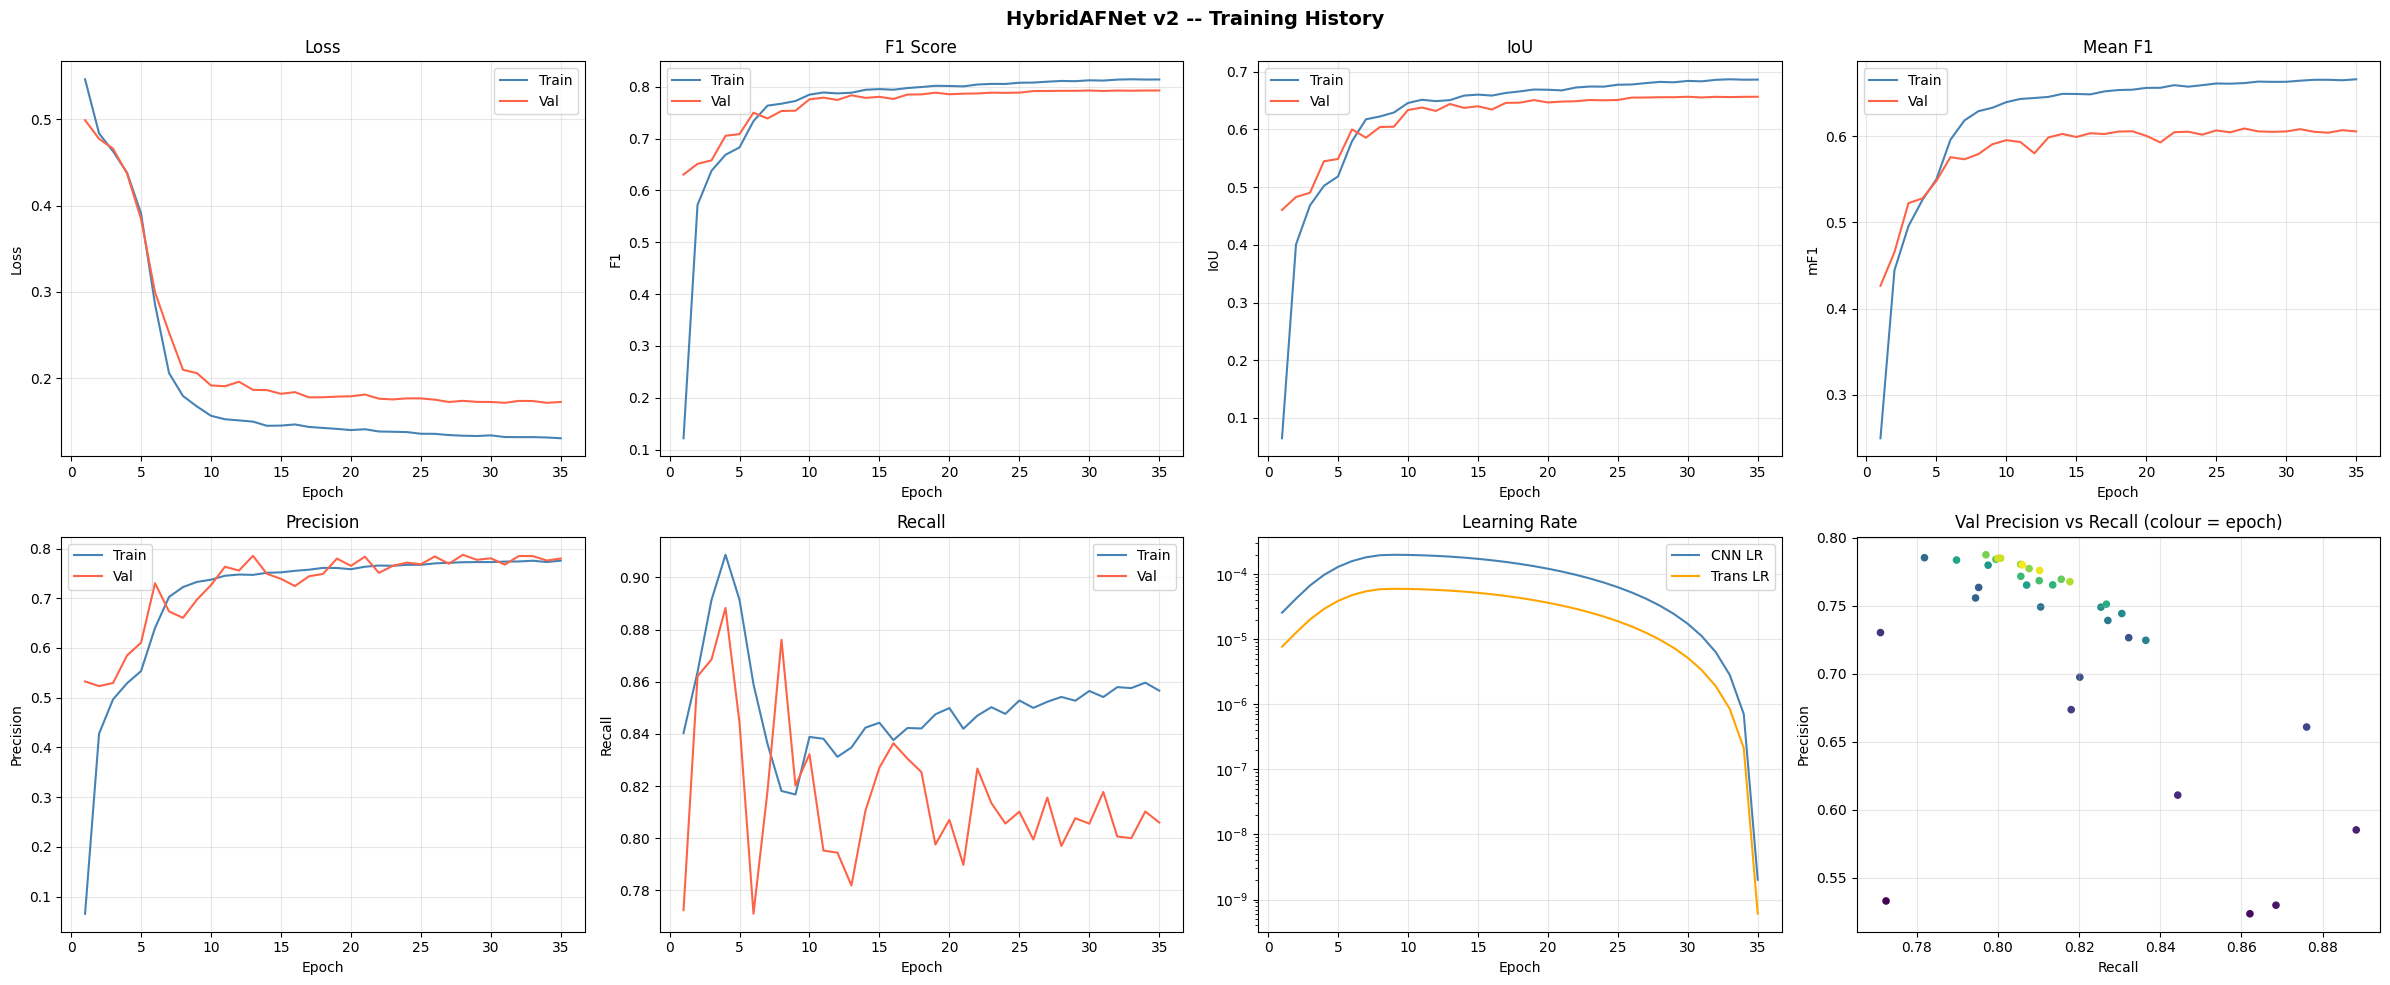

Saved /kaggle/working/training_curves_af_v2.png


In [13]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(2, 4, figsize=(24, 10))

def plot_metric(ax, key, title, ylabel):
    ax.plot(epochs, history[f'train_{key}'], label='Train', color='steelblue')
    ax.plot(epochs, history[f'val_{key}'],   label='Val',   color='tomato')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)

plot_metric(axes[0,0], 'loss',      'Loss',      'Loss')
plot_metric(axes[0,1], 'F1',        'F1 Score',  'F1')
plot_metric(axes[0,2], 'IoU',       'IoU',       'IoU')
plot_metric(axes[0,3], 'mF1',       'Mean F1',   'mF1')
plot_metric(axes[1,0], 'precision', 'Precision', 'Precision')
plot_metric(axes[1,1], 'recall',    'Recall',    'Recall')

axes[1,2].plot(epochs, history['lr_cnn'],   label='CNN LR',   color='steelblue')
axes[1,2].plot(epochs, history['lr_trans'], label='Trans LR', color='orange')
axes[1,2].set_title('Learning Rate')
axes[1,2].set_xlabel('Epoch')
axes[1,2].set_yscale('log')
axes[1,2].legend()
axes[1,2].grid(alpha=0.3)

# Precision vs Recall trade-off
axes[1,3].scatter(history['val_recall'], history['val_precision'],
                  c=list(epochs), cmap='viridis', s=20)
axes[1,3].set_xlabel('Recall')
axes[1,3].set_ylabel('Precision')
axes[1,3].set_title('Val Precision vs Recall (colour = epoch)')
axes[1,3].grid(alpha=0.3)

fig.suptitle('HybridAFNet v2 -- Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, 'training_curves_af_v2.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {out}')


## Validation PR sweep with best checkpoint

Best checkpoint loaded for PR sweep.


PR sweep inference:   0%|          | 0/56 [00:00<?, ?it/s]

Threshold sweep (val set):
   Threshold       F1   Precision    Recall      IoU
  --------------------------------------------------
        0.10   0.7698      0.6750    0.8955   0.6257
        0.15   0.7794      0.7000    0.8791   0.6385
        0.20   0.7842      0.7164    0.8662   0.6450
        0.25   0.7871      0.7289    0.8554   0.6489
        0.30   0.7894      0.7394    0.8466   0.6520
        0.35   0.7902      0.7475    0.8380   0.6531
        0.40   0.7912      0.7557    0.8303   0.6546
        0.45   0.7920      0.7630    0.8233   0.6556  <-- best
        0.50   0.7918      0.7694    0.8155   0.6553
        0.55   0.7913      0.7757    0.8077   0.6547
        0.60   0.7915      0.7827    0.8005   0.6549
        0.65   0.7907      0.7892    0.7922   0.6539
        0.70   0.7894      0.7963    0.7828   0.6521
        0.75   0.7877      0.8042    0.7718   0.6497
        0.80   0.7850      0.8128    0.7590   0.6461
        0.85   0.7808      0.8232    0.7425   0.6404
        0

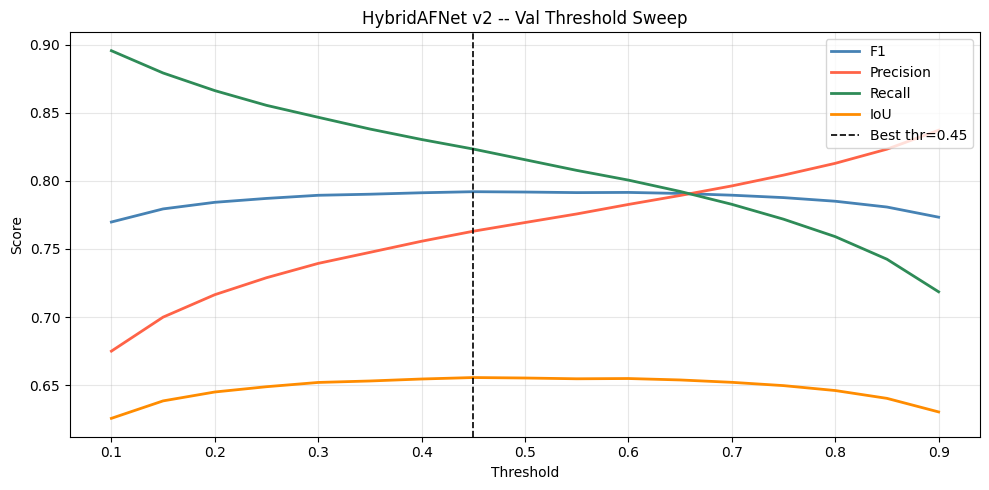

Saved /kaggle/working/threshold_analysis_af_v2.png


In [14]:
eval_model = HybridAFNet(
    in_ch=CHANS_PER_STEP, base_ch=BASE_CH,
    n_heads=N_HEADS, n_layers=N_TRANS_LAYERS,
    ff_dim=TRANS_FF_DIM, dropout=TRANS_DROPOUT
)
state = torch.load(CKPT_BEST, map_location=device)
eval_model.load_state_dict(state)
eval_model = eval_model.to(device)
eval_model.eval()
print('Best checkpoint loaded for PR sweep.')

# Collect probabilities on val set
all_probs  = []
all_labels = []
with torch.no_grad():
    for xb, yb in tqdm(val_loader, desc='PR sweep inference'):
        xb = xb.to(device)
        xb_pad, H0, W0 = pad_to_multiple(xb)
        logits = eval_model(xb_pad)[:, :, :H0, :W0]
        p = torch.softmax(logits.float(), dim=1)[:, 1]
        all_probs.append(p.cpu())
        all_labels.append(yb)

all_probs  = torch.cat(all_probs).numpy().ravel()
all_labels = torch.cat(all_labels).numpy().ravel()

thresholds = np.arange(0.10, 0.95, 0.05)
rows = []
for thr in thresholds:
    pred = (all_probs > thr).astype(int)
    tp = int((pred * all_labels).sum())
    fp = int((pred * (1 - all_labels)).sum())
    fn = int(((1 - pred) * all_labels).sum())
    d_f1  = 2*tp + fp + fn
    d_iou = tp + fp + fn
    f1  = 2*tp / d_f1  if d_f1  > 0 else 0.0
    iou = tp   / d_iou if d_iou > 0 else 0.0
    prec = tp / (tp+fp) if (tp+fp) > 0 else 0.0
    rec  = tp / (tp+fn) if (tp+fn) > 0 else 0.0
    rows.append({'threshold': thr, 'F1': f1, 'IoU': iou, 'Precision': prec, 'Recall': rec})

sweep_df = pd.DataFrame(rows)
best_idx = sweep_df['F1'].idxmax()
best_thr = float(sweep_df.loc[best_idx, 'threshold'])
best_f1  = float(sweep_df.loc[best_idx, 'F1'])

print('Threshold sweep (val set):')
print(f'  {"Threshold":>10}  {"F1":>7}  {"Precision":>10}  {"Recall":>8}  {"IoU":>7}')
print('  ' + '-'*50)
for _, row in sweep_df.iterrows():
    marker = '  <-- best' if abs(row['threshold'] - best_thr) < 1e-4 else ''
    print(f'  {row["threshold"]:>10.2f}  {row["F1"]:>7.4f}  {row["Precision"]:>10.4f}  {row["Recall"]:>8.4f}  {row["IoU"]:>7.4f}{marker}')

print(f'\nBest val threshold : {best_thr:.2f}  (F1={best_f1:.4f})')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep_df['threshold'], sweep_df['F1'],        label='F1',        color='steelblue',  lw=2)
ax.plot(sweep_df['threshold'], sweep_df['Precision'], label='Precision', color='tomato',     lw=2)
ax.plot(sweep_df['threshold'], sweep_df['Recall'],    label='Recall',    color='seagreen',   lw=2)
ax.plot(sweep_df['threshold'], sweep_df['IoU'],       label='IoU',       color='darkorange', lw=2)
ax.axvline(best_thr, color='k', ls='--', lw=1.2, label=f'Best thr={best_thr:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('HybridAFNet v2 -- Val Threshold Sweep')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, 'threshold_analysis_af_v2.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {out}')


## Final validation metrics

In [15]:
val_metrics = FireMetrics()
eval_model.eval()
with torch.no_grad():
    for xb, yb in tqdm(val_loader, desc='Final val eval'):
        xb = xb.to(device)
        yb = yb.to(device)
        xb_pad, H0, W0 = pad_to_multiple(xb)
        logits = eval_model(xb_pad)[:, :, :H0, :W0]
        val_metrics.update(logits, yb, threshold=best_thr)

print('=' * 55)
print('FINAL VAL METRICS  (best checkpoint, best threshold)')
print(f'  Threshold : {best_thr:.2f}')
print(f'  F1        : {val_metrics.F1:.4f}')
print(f'  IoU       : {val_metrics.IoU:.4f}')
print(f'  Precision : {val_metrics.precision:.4f}')
print(f'  Recall    : {val_metrics.recall:.4f}')
print(f'  mF1       : {val_metrics.mF1:.4f}')
print('=' * 55)

print('\nComparison with paper baselines (AF test set F1 from Table 3):')
baselines = [
    ('GRU-3',        0.713, 0.601, '64.3K'),
    ('U-Net 2D',     0.731, 0.605, '10.6M'),
    ('U-Net-3D',     0.748, 0.628, '31.7M'),
    ('LSTM-3',       0.765, 0.654, '84.9K'),
    ('SwinUNETR-3D', 0.797, 0.688, '33.2M'),
    ('T4Fire',       0.802, 0.700, '32.5K'),
    ('UNETR-3D',     0.811, 0.706, '34.8M'),
]
n_params = sum(p.numel() for p in eval_model.parameters())
print(f'  {"Model":<22}  {"F1":>6}  {"IoU":>6}  {"Params":>8}')
print('  ' + '-'*50)
for name, f1, iou, params in baselines:
    print(f'  {name:<22}  {f1:>6.3f}  {iou:>6.3f}  {params:>8}')
print(f'  {"HybridAFNet v2 (ours)":<22}  {val_metrics.F1:>6.3f}  {val_metrics.IoU:>6.3f}  {n_params/1e6:>7.2f}M')


Final val eval:   0%|          | 0/56 [00:00<?, ?it/s]

FINAL VAL METRICS  (best checkpoint, best threshold)
  Threshold : 0.45
  F1        : 0.7920
  IoU       : 0.6556
  Precision : 0.7630
  Recall    : 0.8233
  mF1       : 0.6106

Comparison with paper baselines (AF test set F1 from Table 3):
  Model                       F1     IoU    Params
  --------------------------------------------------
  GRU-3                    0.713   0.601     64.3K
  U-Net 2D                 0.731   0.605     10.6M
  U-Net-3D                 0.748   0.628     31.7M
  LSTM-3                   0.765   0.654     84.9K
  SwinUNETR-3D             0.797   0.688     33.2M
  T4Fire                   0.802   0.700     32.5K
  UNETR-3D                 0.811   0.706     34.8M
  HybridAFNet v2 (ours)    0.792   0.656     8.52M


## Save outputs and zip

In [16]:
output_files = [
    'af_hybrid_v2_best.pt',
    'af_hybrid_v2_last.pt',
    'norm_stats_af_v2.npz',
    'run_meta_af_v2.json',
    'history_af_v2.json',
    'training_curves_af_v2.png',
    'threshold_analysis_af_v2.png',
]

zip_path = os.path.join(OUTPUT_DIR, 'af_hybrid_v2_outputs.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in output_files:
        fpath = os.path.join(OUTPUT_DIR, fname)
        if os.path.exists(fpath):
            zf.write(fpath, arcname=fname)
            size_kb = os.path.getsize(fpath) / 1024
            print(f'  added  {fname:<45} {size_kb:>8.1f} KB')
        else:
            print(f'  SKIP   {fname:<45} (not found)')

zip_size = os.path.getsize(zip_path) / 1024**2
print(f'\nZip : {zip_path}  ({zip_size:.1f} MB)')

print('\nAll /kaggle/working files:')
print('=' * 60)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if not os.path.isfile(fpath): continue
    sz  = os.path.getsize(fpath)
    u   = 'MB' if sz >= 1024**2 else 'KB'
    val = sz/1024**2 if u == 'MB' else sz/1024
    print(f'  {fname:<50} {val:>7.1f} {u}')


  added  af_hybrid_v2_best.pt                           33363.9 KB
  added  af_hybrid_v2_last.pt                           33363.9 KB
  added  norm_stats_af_v2.npz                               1.2 KB
  added  run_meta_af_v2.json                                3.6 KB
  added  history_af_v2.json                                10.0 KB
  added  training_curves_af_v2.png                        318.5 KB
  added  threshold_analysis_af_v2.png                      82.1 KB

Zip : /kaggle/working/af_hybrid_v2_outputs.zip  (60.5 MB)

All /kaggle/working files:
  __notebook__.ipynb                                   445.3 KB
  af_hybrid_v2_best.pt                                  32.6 MB
  af_hybrid_v2_last.pt                                  32.6 MB
  af_hybrid_v2_outputs.zip                              60.5 MB
  history_af_v2.json                                    10.0 KB
  norm_stats_af_v2.npz                                   1.2 KB
  run_meta_af_v2.json                                    3.6